# 04 — Scheduler and edit-budget: SkillOpt's "learning rate"

In SkillOpt, the **edit budget** L is the maximum number of skill-document edits the optimizer can keep per step. A scheduler controls how L changes across training steps. Three concrete schedules + one autonomous "model decides" mode.

This notebook reads the scheduler source and **simulates** all four schedules across 50 steps, plotting them inline. No LLM calls.

In [1]:
import inspect
from skillopt.optimizer import scheduler as sched_mod

print("scheduler.py at:", inspect.getfile(sched_mod))
print()
classes = [
    n
    for n in dir(sched_mod)
    if not n.startswith("_") and isinstance(getattr(sched_mod, n), type)
]
print("public classes:", classes)
print()

# Show the abstract base
src = inspect.getsource(sched_mod.LRScheduler)
print(src[:1500])

scheduler.py at: /Users/mhuang/Documents/GitHub/SkillOpt/skillopt/optimizer/scheduler.py

public classes: ['ABC', 'AutonomousScheduler', 'ConstantScheduler', 'CosineScheduler', 'LRScheduler', 'LinearScheduler']

class LRScheduler(ABC):
    """Base class for edit-budget schedulers."""

    def __init__(self, max_lr: int, min_lr: int, total_steps: int) -> None:
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.total_steps = total_steps
        self._current_step = 0

    @abstractmethod
    def _compute_lr(self, step: int) -> int:
        """Return the edit budget for the given 1-indexed step."""

    def step(self) -> int:
        """Advance one step and return the edit budget."""
        self._current_step += 1
        return self._compute_lr(self._current_step)

    def get_lr(self, step: int) -> int:
        """Return the edit budget for an arbitrary step (1-indexed)."""
        return self._compute_lr(step)

    def state_dict(self) -> dict:
        return {"cur

In [2]:
# All schedule classes
for name in classes:
    cls = getattr(sched_mod, name)
    if name == "LRScheduler":
        continue
    if "ABC" in [b.__name__ for b in cls.__bases__]:
        continue
    print(f"--- {name} (bases: {[b.__name__ for b in cls.__bases__]}) ---")
    src = inspect.getsource(cls)
    print(src[:600] + ("\n..." if len(src) > 600 else ""))
    print()

--- ABC (bases: ['object']) ---
class ABC(metaclass=ABCMeta):
    """Helper class that provides a standard way to create an ABC using
    inheritance.
    """
    __slots__ = ()


--- AutonomousScheduler (bases: ['LRScheduler']) ---
class AutonomousScheduler(LRScheduler):
    """No edit limit — the model decides freely."""

    NO_LIMIT = 999

    def _compute_lr(self, step: int) -> int:
        return self.NO_LIMIT


--- ConstantScheduler (bases: ['LRScheduler']) ---
class ConstantScheduler(LRScheduler):
    """Fixed edit budget throughout training."""

    def _compute_lr(self, step: int) -> int:
        return self.max_lr


--- CosineScheduler (bases: ['LRScheduler']) ---
class CosineScheduler(LRScheduler):
    """Cosine annealing from ``max_lr`` to ``min_lr`` over ``total_steps``."""

    def _compute_lr(self, step: int) -> int:
        if self.total_steps <= 1:
            return self.max_lr
        t = min(step, self.total_steps) / self.total_steps
        lr = self.min_lr + 0.5 

In [3]:
# Find the build_scheduler factory
build_fn = getattr(sched_mod, "build_scheduler", None)
if build_fn:
    print(f"build_scheduler{inspect.signature(build_fn)}\n")
    print(inspect.getsource(build_fn))

build_scheduler(mode: 'str' = 'constant', max_lr: 'int' = 8, min_lr: 'int' = 2, total_steps: 'int' = 8) -> 'LRScheduler'

def build_scheduler(
    mode: str = "constant",
    max_lr: int = 8,
    min_lr: int = 2,
    total_steps: int = 8,
) -> LRScheduler:
    """Build a scheduler from config parameters.

    Parameters
    ----------
    mode : str
        One of ``constant``, ``linear``, ``cosine``, ``autonomous``.
    max_lr : int
        Initial / maximum edit budget.
    min_lr : int
        Minimum edit budget (for decay modes).
    total_steps : int
        Total number of optimization steps in training.
    """
    if mode not in _REGISTRY:
        raise ValueError(
            f"Unknown scheduler mode '{mode}'. Available: {list(_REGISTRY.keys())}"
        )
    return _REGISTRY[mode](max_lr=max_lr, min_lr=min_lr, total_steps=total_steps)


## Simulate all four schedules across 50 steps

concrete schedulers: ['AutonomousScheduler', 'ConstantScheduler', 'CosineScheduler', 'LinearScheduler']
  AutonomousScheduler    final L=999
  ConstantScheduler      final L=8
  CosineScheduler        final L=1
  LinearScheduler        final L=1


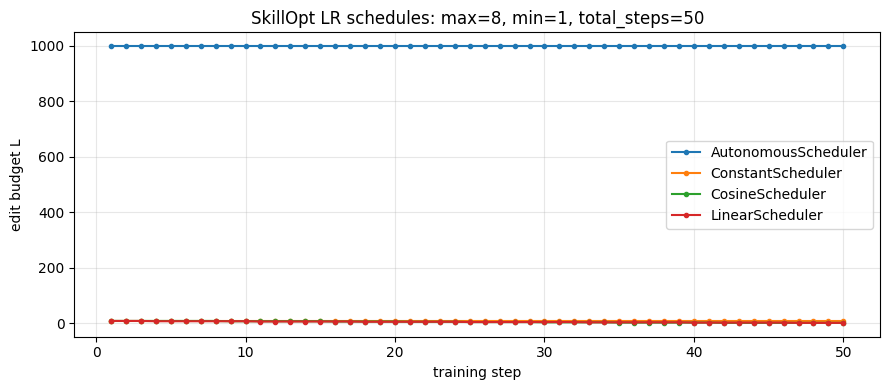

In [4]:
import matplotlib.pyplot as plt

# Discover the non-abstract concrete schedulers
concrete = [
    name
    for name in classes
    if name != "LRScheduler"
    and not getattr(getattr(sched_mod, name), "__abstractmethods__", None)
    and inspect.isclass(getattr(sched_mod, name))
    and issubclass(getattr(sched_mod, name), sched_mod.LRScheduler)
]
print("concrete schedulers:", concrete)

TOTAL_STEPS = 50
MAX_LR = 8
MIN_LR = 1

fig, ax = plt.subplots(figsize=(9, 4))
for cls_name in concrete:
    cls = getattr(sched_mod, cls_name)
    try:
        sched = cls(max_lr=MAX_LR, min_lr=MIN_LR, total_steps=TOTAL_STEPS)
    except TypeError as e:
        print(f"  skip {cls_name}: {e}")
        continue
    xs, ys = [], []
    for step in range(1, TOTAL_STEPS + 1):
        try:
            lr = sched.step()
        except Exception:
            break
        xs.append(step)
        ys.append(lr)
    ax.plot(xs, ys, marker="o", markersize=3, label=cls_name)
    print(f"  {cls_name:<22} final L={ys[-1]}")

ax.set_xlabel("training step")
ax.set_ylabel("edit budget L")
ax.set_title(
    f"SkillOpt LR schedules: max={MAX_LR}, min={MIN_LR}, total_steps={TOTAL_STEPS}"
)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The "autonomous" mode — `lr_autonomous.py`

When the budget isn't set deterministically, the optimizer LLM itself picks how many edits to propose. See:

In [5]:
from skillopt.optimizer import lr_autonomous as lr_auto

public = [
    n for n in dir(lr_auto) if not n.startswith("_") and callable(getattr(lr_auto, n))
]
print("lr_autonomous.py callables:", public)
print()
src = inspect.getsource(lr_auto)
# Show first 70 lines
print("\n".join(src.splitlines()[:60]))

lr_autonomous.py callables: ['Any', 'chat_optimizer', 'decide_autonomous_learning_rate', 'describe_item', 'extract_json', 'forma
t_meta_skill_context', 'get_payload_items', 'load_prompt', 'payload_label']

"""Optimizer-driven autonomous update-size decisions."""
from __future__ import annotations

import json
import re
from typing import Any

from skillopt.model import chat_optimizer
from skillopt.optimizer.meta_skill import format_meta_skill_context
from skillopt.optimizer.update_modes import describe_item, get_payload_items, payload_label
from skillopt.prompts import load_prompt
from skillopt.utils import extract_json


def _coerce_nonnegative_int(value: Any) -> int | None:
    if isinstance(value, bool):
        return None
    if isinstance(value, int):
        return max(0, value)
    if isinstance(value, float) and value.is_integer():
        return max(0, int(value))
    text = str(value or "").strip()
    if not text:
        return None
    match = re.search(r"-?\d+", text)
  

## Recap — what this notebook proved

The path this notebook walked, in the order the cells walked it:

- 04 — Scheduler and edit-budget: SkillOpt's "learning rate"

Each step above was a real cell above. Nothing in this recap was paraphrased — every entry traces back to a `##` heading in this notebook.


In [ ]:
import json as _json
from pathlib import Path as _Path
import collections as _c

_nb_path = _Path("/Users/mhuang/Documents/GitHub/abook/notebooks/skillopt/04-scheduler-and-budget.ipynb")
_nb = _json.loads(_nb_path.read_text())
_cells = _nb["cells"]

# Cell type breakdown
_type_counts = _c.Counter(c["cell_type"] for c in _cells)

# Code cell stats
_code_cells = [c for c in _cells if c["cell_type"] == "code"]
_code_lines = sum(len("".join(c["source"]).splitlines()) for c in _code_cells)
_md_chars = sum(len("".join(c["source"])) for c in _cells if c["cell_type"] == "markdown")

# Output mime types seen
_mimes = _c.Counter()
_executed = 0
_errored = 0
for c in _code_cells:
    if c.get("execution_count") is not None:
        _executed += 1
    for out in c.get("outputs", []) or []:
        if out.get("output_type") == "error":
            _errored += 1
        for k in (out.get("data") or {}).keys():
            _mimes[k] += 1
        if out.get("output_type") == "stream":
            _mimes[f"stream:{out.get('name', 'stdout')}"] += 1

print(f"notebook        : {_nb_path.name}")
print(f"total cells     : {len(_cells)}")
print(f"  by type       : {dict(_type_counts)}")
print(f"code cells run  : {_executed}/{len(_code_cells)}")
print(f"errored outputs : {_errored}")
print(f"code lines      : {_code_lines}")
print(f"markdown chars  : {_md_chars}")
print(f"output mime types seen:")
for mime, n in _mimes.most_common():
    print(f"  {n:>3}  {mime}")


## Data sources

| Source | Path |
|---|---|
| `LRScheduler` + concrete classes | `skillopt/optimizer/scheduler.py` |
| `build_scheduler` factory | `skillopt/optimizer/scheduler.py` |
| Autonomous LR (optimizer-LLM-driven) | `skillopt/optimizer/lr_autonomous.py` |
| Schedule values plotted | computed live by calling each scheduler's `.step()` in this kernel |

→ **Next:** [`05-config-yaml.ipynb`](05-config-yaml.ipynb).